In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


In [16]:
from sklearn.datasets import load_diabetes

In [17]:
ds=load_diabetes()

In [18]:
print(ds.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [22]:
X=pd.DataFrame(ds.data,columns=['age','sex','bmi','bp','s1','s2','s3','s4','s5','s6'])

In [23]:
y=ds['target']

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=24)

In [25]:
X_train.corr()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.202978,0.183080,0.360476,0.243424,0.209394,-0.096058,0.227149,0.262633,0.327373
sex,0.202978,1.000000,0.074817,0.245343,0.036647,0.137588,-0.355179,0.313992,0.113804,0.184779
bmi,0.183080,0.074817,1.000000,0.418915,0.265892,0.264924,-0.346105,0.399315,0.446921,0.429972
bp,0.360476,0.245343,0.418915,1.000000,0.240663,0.188786,-0.191050,0.260962,0.389412,0.423253
s1,0.243424,0.036647,0.265892,0.240663,1.000000,0.896658,0.075066,0.553898,0.495856,0.341310
s2,0.209394,0.137588,0.264924,0.188786,0.896658,1.000000,-0.164012,0.653909,0.276022,0.297712
s3,-0.096058,-0.355179,-0.346105,-0.191050,0.075066,-0.164012,1.000000,-0.714074,-0.363570,-0.278038
s4,0.227149,0.313992,0.399315,0.260962,0.553898,0.653909,-0.714074,1.000000,0.597847,0.436874
s5,0.262633,0.113804,0.446921,0.389412,0.495856,0.276022,-0.363570,0.597847,1.000000,0.476539
s6,0.327373,0.184779,0.429972,0.423253,0.341310,0.297712,-0.278038,0.436874,0.476539,1.000000


<Axes: >

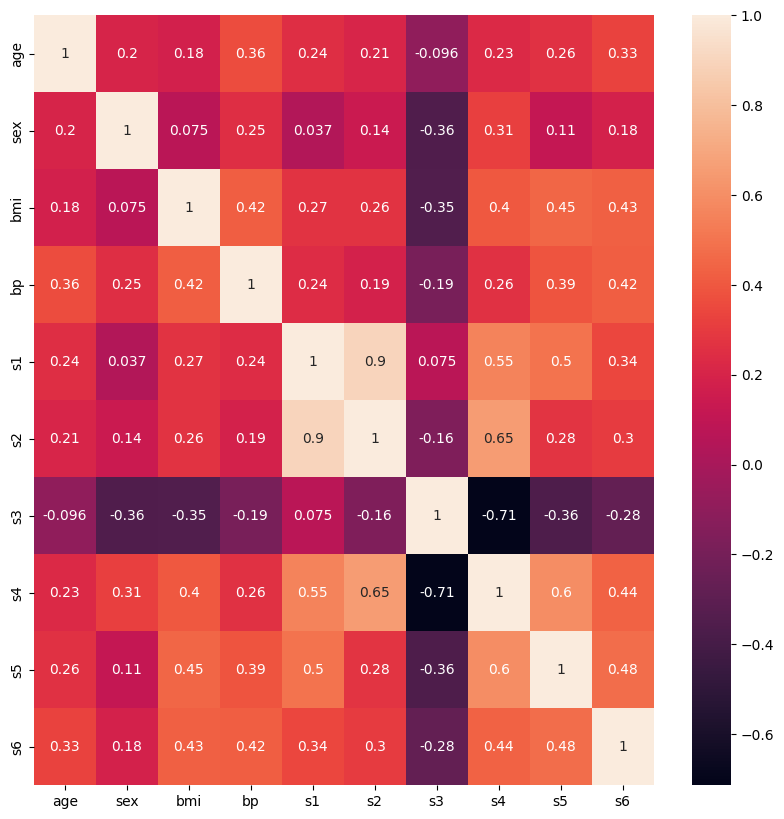

In [29]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(X_train.corr(),annot=True)

In [30]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor()

In [31]:
param={
    'criterion':['squared_error','friedman_mse','absolute_error','poisson'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,10,15,20,25],
    'max_features':['auto','sqrt','log2']
}

In [38]:
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(regressor,param_grid=param,cv=5,scoring='neg_mean_squared_error')

In [39]:
import warnings
warnings.filterwarnings('ignore')
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error', 'poisson'],
                         'max_depth': [1, 2, 3, 4, 5, 10, 15, 20, 25],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error')

In [40]:
grid.best_params_

{'criterion': 'friedman_mse',
 'max_depth': 4,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [41]:
y_pred=grid.predict(X_test)

In [42]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.18123055187276138
56.582832925805064
4714.029511922626


In [44]:
model=DecisionTreeRegressor(
criterion='friedman_mse',
max_depth= 4,
max_features= 'sqrt',
splitter= 'best')

In [45]:
model.fit(X_train,y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=4,
                      max_features='sqrt')

[Text(0.5, 0.9, 'x[8] <= 0.022\nfriedman_mse = 5965.265\nsamples = 331\nvalue = 154.508'),
 Text(0.25, 0.7, 'x[8] <= -0.033\nfriedman_mse = 3950.77\nsamples = 218\nvalue = 124.353'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'x[2] <= 0.01\nfriedman_mse = 1935.743\nsamples = 81\nvalue = 96.901'),
 Text(0.0625, 0.3, 'x[1] <= 0.003\nfriedman_mse = 1500.134\nsamples = 67\nvalue = 89.015'),
 Text(0.03125, 0.1, 'friedman_mse = 1734.909\nsamples = 44\nvalue = 98.0'),
 Text(0.09375, 0.1, 'friedman_mse = 601.1\nsamples = 23\nvalue = 71.826'),
 Text(0.1875, 0.3, 'x[0] <= -0.056\nfriedman_mse = 2298.372\nsamples = 14\nvalue = 134.643'),
 Text(0.15625, 0.1, 'friedman_mse = 42.25\nsamples = 2\nvalue = 193.5'),
 Text(0.21875, 0.1, 'friedman_mse = 2000.806\nsamples = 12\nvalue = 124.833'),
 Text(0.375, 0.5, 'x[9] <= 0.076\nfriedman_mse = 4433.133\nsamples = 137\nvalue = 140.584'),
 Text(0.3125, 0.3, 'x[5] <= 0.018\nfriedman_mse = 4083.007\nsamples = 131\nvalue = 136.985'),
 Text(0.28125, 0.1, 'f

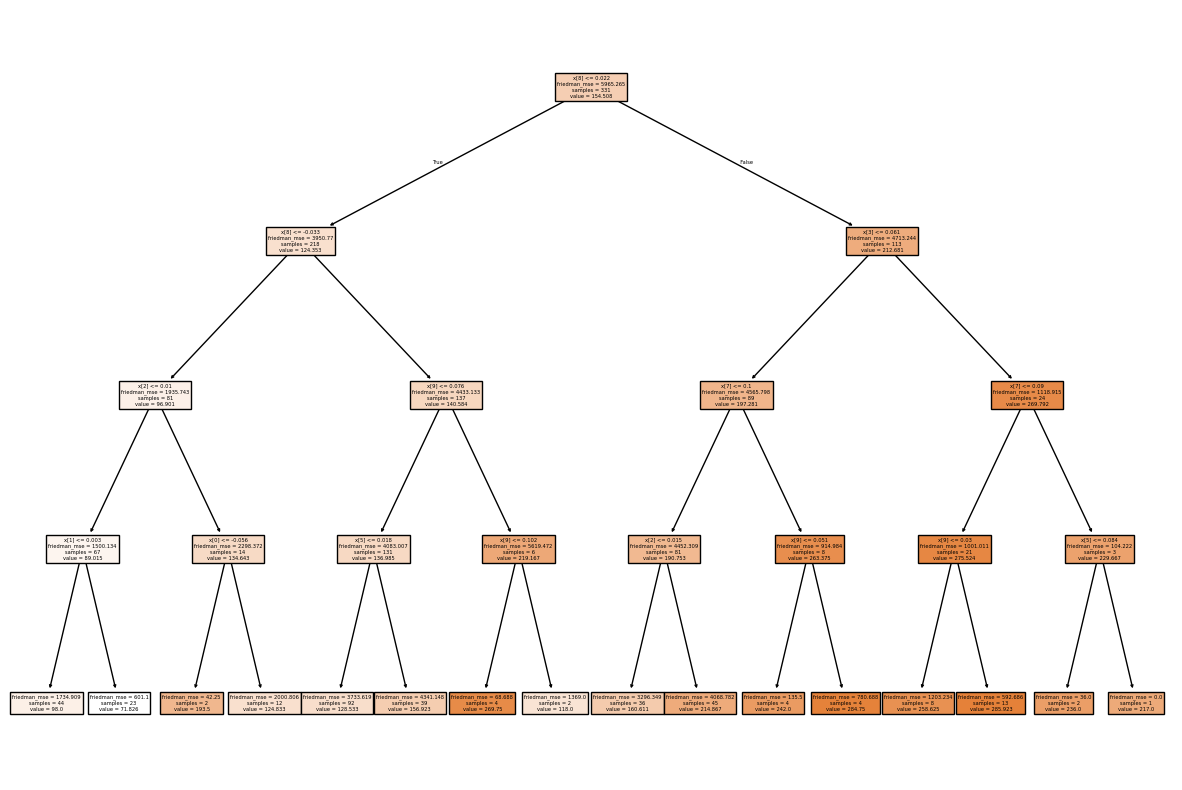

In [48]:
##Visualize the Decision Tree
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(model,filled=True)